# RCWA flow field
从全局x,y坐标投影改成局部坐标投影，避免介电常数的突变引起的吉布斯效应，提高 rcwa 收敛性。

In [1]:
%matplotlib inline
from simulation import *
import numpy as np
import matplotlib.pyplot as plt

# 高分辨率网格使 ε 更光滑；箭头单独用 stride 稀疏采样
nu = nv = 256
quiver_stride = 16  # ~16x16 箭头，避免遮挡底图
wavelength = 1.0
pitch = 1.0  # unit orthogonal cell, matches rcwa_pol_nv_flow_field_s
NA = 1.0

grid_info_2d = grid_info_2d_s.create_bloch_mode_fourier(
    [nu, nv], wavelength, 0.0, NA,
    [[-pitch / 2, -pitch / 2], [pitch / 2, pitch / 2]],
)
xsize, ysize = grid_info_2d.shape

mat_bg = share_material_s(material_s.from_epsilon(12 + 0j, "Si"))
mat_pat = share_material_s(material_s.from_epsilon(1 + 0j, "Vac"))
mat_hi = share_material_s(material_s.from_epsilon(16 + 0j, "Hi"))


def make_pattern_layer(*shapes_and_parents):
    lyr = layer_s()
    lyr.background_material = mat_bg
    lyr.depth = 0.5
    shapes, parents = [], []
    for item in shapes_and_parents:
        if isinstance(item, tuple):
            sh, p = item
        else:
            sh, p = item, -1
        shapes.append(sh)
        parents.append(p)
    lyr.shapes = shapes
    lyr.parent = parents
    return lyr


def epsilon_ifft_from_layer(lyr):
    """闭式 FT (fourier_transform_mask) → IFFT → 实空间 ε。"""
    fft = raster_layer_fourier_transform_s(lyr, grid_info_2d, wavelength)
    spec = np.asarray(fft, dtype=np.complex64).reshape((ysize, xsize))
    spatial = (xsize * ysize) * np.fft.fftshift(np.fft.ifft2(spec))
    return spatial  # shape (ysize, xsize)


def plot_flow(title, lyr):
    eps = epsilon_ifft_from_layer(lyr)
    eps_show = np.real(eps)

    # 先取原始流场，避免 unit_normalize=True 将零向量填充为统一方向
    vf = rcwa_pol_nv_flow_field_s(lyr, nu, nv, unit_normalize=False)
    assert vf.shape == (nu, nv, 2), vf.shape
    vx, vy = vf[:, :, 0], vf[:, :, 1]

    # 仅对非零向量做归一化，近零向量不画箭头，避免“整图同向”的伪象
    mag = np.hypot(vx, vy)
    thr = max(1e-12, 1e-3 * np.max(mag))
    valid = mag > thr
    vxn = np.zeros_like(vx)
    vyn = np.zeros_like(vy)
    vxn[valid] = vx[valid] / mag[valid]
    vyn[valid] = vy[valid] / mag[valid]

    xs = np.linspace(-0.5, 0.5, nu, endpoint=False) + 0.5 / nu
    ys = np.linspace(-0.5, 0.5, nv, endpoint=False) + 0.5 / nv
    X, Y = np.meshgrid(xs, ys, indexing="ij")

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.pcolormesh(xs, ys, eps_show, shading="auto", cmap="viridis", alpha=0.95)
    fig.colorbar(im, ax=ax, fraction=0.046, label=r"$\mathrm{Re}(\varepsilon)$")

    s = quiver_stride
    # 白边黑箭头：在彩色底图上可读；scale 较大 → 箭头较短；width 细
    ax.quiver(
        X[::s, ::s], Y[::s, ::s], vxn[::s, ::s], vyn[::s, ::s],
        color="white",
        edgecolor="black",
        linewidth=0.35,
        angles="xy",
        scale_units="xy",
        scale=18,
        width=0.004,
        headwidth=3.2,
        headlength=4.0,
        headaxislength=3.5,
        pivot="mid",
        zorder=3,
    )
    valid_ratio = float(np.mean(valid))
    ax.set_title(f"{title}: ε (FT→IFFT) + NV flow [v2, valid={valid_ratio:.3f}]")
    ax.set_aspect("equal")
    ax.set_xlim(-0.5, 0.5)
    ax.set_ylim(-0.5, 0.5)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()
    return vf, eps

## Circle

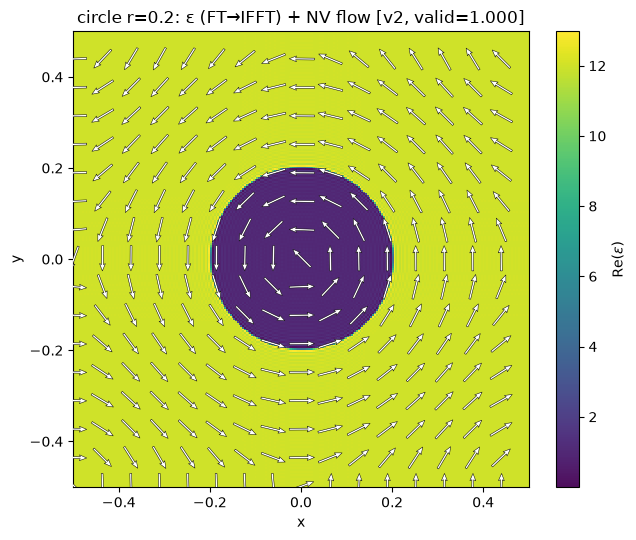

float32 (256, 256, 2) |v| mean 0.364873468875885
eps Re mean/min/max 10.617698669433592 0.0017455733781579497 12.977916924992304


In [2]:
lyr_circle = make_pattern_layer(make_circle_shape_s(0.2, [0.0, 0.0], 0.0, mat_pat))
vf_circle, eps_circle = plot_flow("circle r=0.2", lyr_circle)
print(vf_circle.dtype, vf_circle.shape, "|v| mean", float(np.mean(np.hypot(vf_circle[..., 0], vf_circle[..., 1]))))
print("eps Re mean/min/max", float(np.real(eps_circle).mean()), float(np.real(eps_circle).min()), float(np.real(eps_circle).max()))


## Rectangle

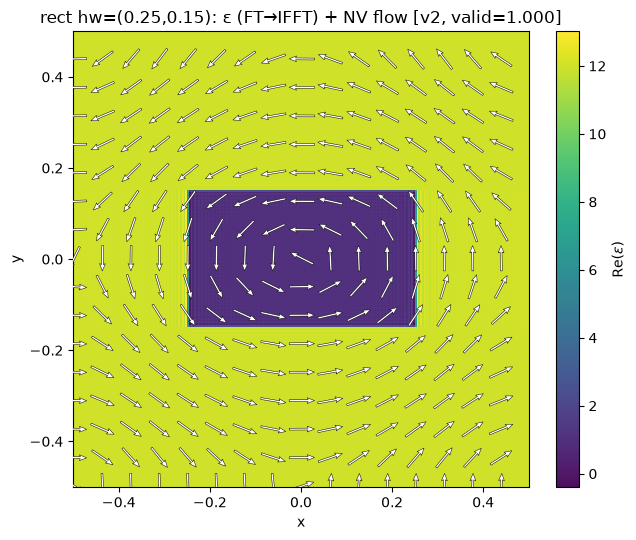

In [3]:
lyr_rect = make_pattern_layer(make_rect_shape_s([0.25, 0.15], [0.0, 0.0], 0.0, mat_pat))
_ = plot_flow("rect hw=(0.25,0.15)", lyr_rect)

## Ellipse

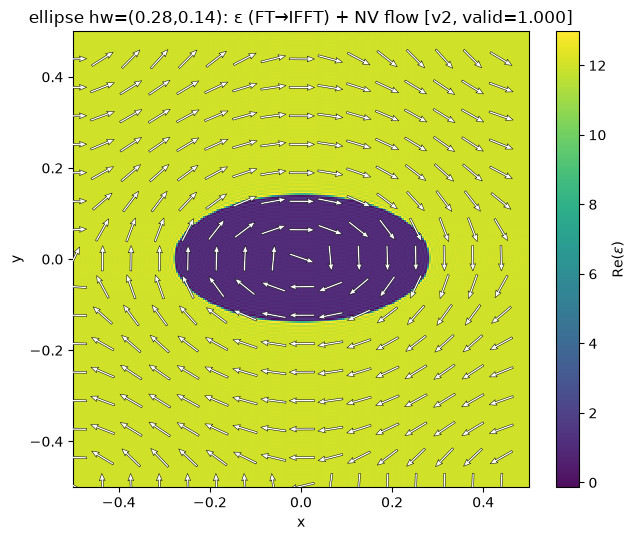

In [4]:
lyr_ell = make_pattern_layer(make_ellipse_shape_s([0.28, 0.14], [0.0, 0.0], 0.0, mat_pat))
_ = plot_flow("ellipse hw=(0.28,0.14)", lyr_ell)

## Triangle (polygon)

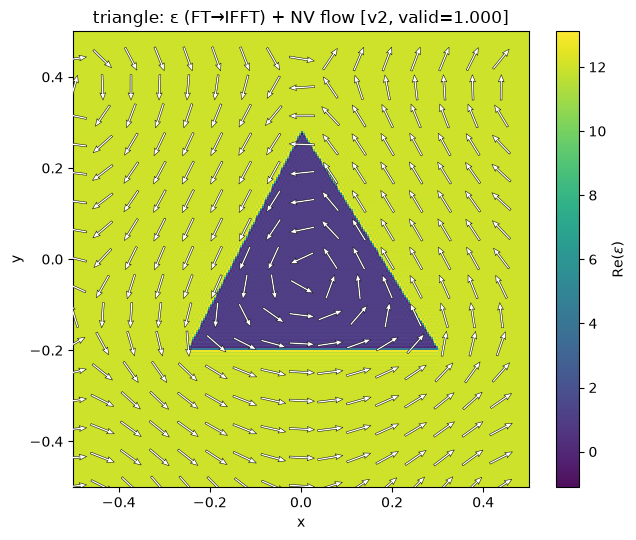

In [5]:
tri = [[-0.25, -0.2], [0.3, -0.2], [0.0, 0.28]]
lyr_tri = make_pattern_layer(make_poly_shape_s(tri, [0.0, 0.0], 0.0, mat_pat))
_ = plot_flow("triangle", lyr_tri)

## Donut（外圆 + 内圆）

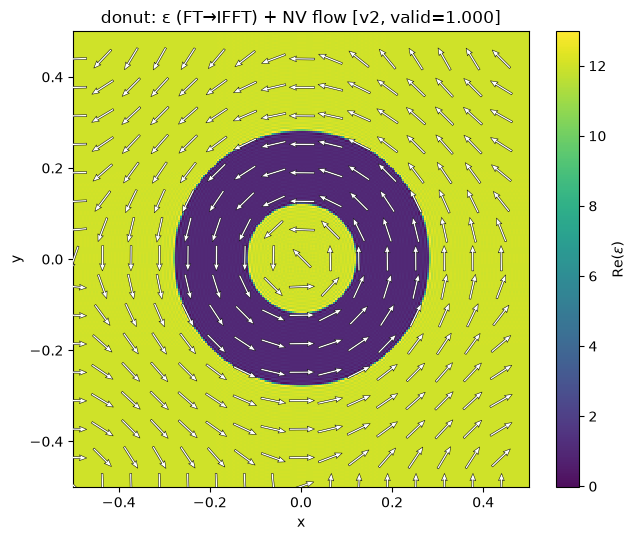

In [6]:
lyr_donut = make_pattern_layer(
    make_circle_shape_s(0.28, [0.0, 0.0], 0.0, mat_pat),
    (make_circle_shape_s(0.12, [0.0, 0.0], 0.0, mat_bg), 0),
)
_ = plot_flow("donut", lyr_donut)

## Multi（rect + 偏置 circle）

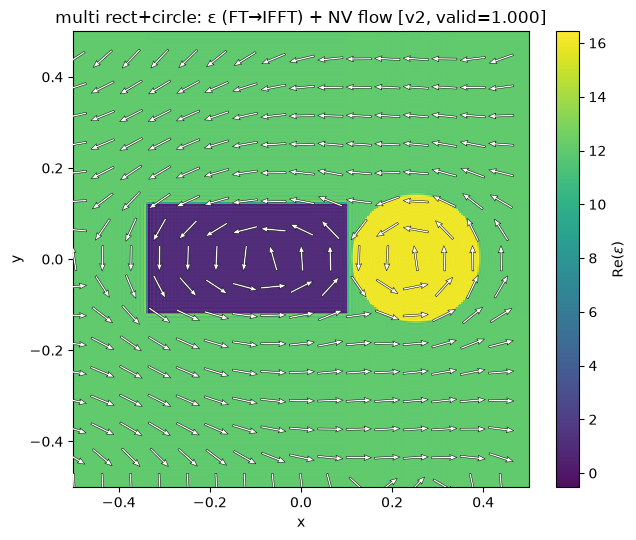

In [7]:
lyr_multi = make_pattern_layer(
    make_rect_shape_s([0.22, 0.12], [-0.12, 0.0], 0.0, mat_pat),
    make_circle_shape_s(0.14, [0.25, 0.0], 0.0, mat_hi),
)
_ = plot_flow("multi rect+circle", lyr_multi)

## basic vs pol_nv 收敛性对比

**结论先行**：在介电 Li Cell A（低对比、s/p）上，`basic` 与 `pol_nv` 的 \(G=(1,1)\) 衍射效率几乎落到同一渐近值；**不能**据此证明 basic「更差」。
原因：`rcwa_mode_provider_basic` 已按 Li 规则组装 \(\varepsilon\)/\(\varepsilon^{-1}\)；`pol_nv` 是在此之上加偏振分解 / NV 基（并提供 flow field），并非「错误因式分解 vs 正确因式分解」。

下面用经典 **Li JOSA A 14 Cell A**（棋盘两方块、\(\varepsilon=2.25/1\)、\(L=2.5\)、\(\lambda=1\)）画两条收敛曲线作对照；随后用多样片元只展示 ε+NV flow 与短波长下场图。


In [8]:
# --- Convergence: classic Li Cell A (meaningful G=(1,1) ~0.12) ---
sidelen = 1.25
L = sidelen * 2  # 2.5
Lr = [L, 0.0, 0.0, L]
wl_li = 1.0
depth_slab = 1.0
ngs = [21, 41, 61, 81, 101]
nxy_field = [96, 96]
# Field viz: shorter λ so |E|,|H| resolve feature scale (~0.2–0.4).
wl_field = 0.25


def _mat_d(name, eps):
    return share_material_d(material_d.from_epsilon(eps, name))


def _mat_s(name, eps):
    return share_material_s(material_s.from_epsilon(eps, name))


def make_li_cell_a_d():
    diel = _mat_d("Dielectric", 2.25 + 0j)
    vac = _mat_d("Vacuum", 1 + 0j)
    hw = 0.5 * sidelen
    before = layer_d(); before.background_material = diel; before.depth = 0.0
    slab = layer_d(); slab.background_material = vac; slab.depth = depth_slab
    slab.shapes = [
        make_rect_shape_d([hw, hw], [-0.5 * sidelen, -0.5 * sidelen], 0.0, diel),
        make_rect_shape_d([hw, hw], [0.5 * sidelen, 0.5 * sidelen], 0.0, diel),
    ]
    slab.parent = [-1, -1]
    after = layer_d(); after.background_material = vac; after.depth = 0.0
    return [before, slab, after]


layers_li = make_li_cell_a_d()

# --- Complex pattern (visualizer 2D kinds) for ε / NV / fields only ---
_GRID = [(-0.75, 0.5), (0.0, 0.5), (0.75, 0.5), (-0.75, -0.5), (0.0, -0.5), (0.75, -0.5)]


def _scale_xy(v, s):
    return [float(v[0]) * s, float(v[1]) * s]


def _quad_bezier_poly(segments, n_per_seg=12):
    pts = []
    for p0, p1, p2 in segments:
        for k in range(n_per_seg):
            t = k / n_per_seg
            u = 1.0 - t
            pts.append([
                u * u * p0[0] + 2 * u * t * p1[0] + t * t * p2[0],
                u * u * p0[1] + 2 * u * t * p1[1] + t * t * p2[1],
            ])
    return pts


def build_complex_shapes(make_circle, make_ellipse, make_rect, make_poly, make_conc,
                         diel, vac, scale=1.0):
    c0, c1, c2, c3, c4, c5 = [_scale_xy(c, scale) for c in _GRID]
    p0, p1, p2 = [_scale_xy(p, scale) for p in ([-0.16, -0.12], [0.18, -0.12], [0.02, 0.22])]
    poly_verts = [_scale_xy(v, scale) for v in (
        [-0.22, -0.16], [0.22, -0.16], [0.22, 0.00], [0.00, 0.00], [0.00, 0.26], [-0.22, 0.26],
    )]
    bez_segs = [
        [p0, _scale_xy([0.01, -0.22], scale), p1],
        [p1, _scale_xy([0.28, 0.08], scale), p2],
        [p2, _scale_xy([-0.20, 0.10], scale), p0],
    ]
    return [
        make_circle(0.20 * scale, list(c0), 0.0, diel),
        make_ellipse([0.26 * scale, 0.14 * scale], list(c1), 0.35, diel),
        make_rect([0.20 * scale, 0.12 * scale], list(c2), 0.0, diel),
        make_poly(poly_verts, list(c3), 0.0, diel),
        make_poly(_quad_bezier_poly(bez_segs), list(c4), 0.0, diel),
        make_conc(
            [0.07 * scale, 0.16 * scale, 0.26 * scale],
            [diel, vac, diel],
            list(c5), 0.0,
        ),
    ]


diel_d = _mat_d("Dielectric", 2.25 + 0j)
vac_d = _mat_d("Vacuum", 1 + 0j)
shapes_d = build_complex_shapes(
    make_circle_shape_d, make_ellipse_shape_d, make_rect_shape_d,
    make_poly_shape_d, make_concentric_circles_shape_d,
    diel_d, vac_d, scale=1.0,
)
before = layer_d(); before.background_material = diel_d; before.depth = 0.0
slab_c = layer_d(); slab_c.background_material = vac_d; slab_c.depth = depth_slab
slab_c.shapes = shapes_d; slab_c.parent = [-1] * len(shapes_d)
after = layer_d(); after.background_material = vac_d; after.depth = 0.0
layers_complex = [before, slab_c, after]

diel_s = _mat_s("Dielectric", 2.25 + 0j)
vac_s = _mat_s("Vacuum", 1 + 0j)
shapes_s_unit = build_complex_shapes(
    make_circle_shape_s, make_ellipse_shape_s, make_rect_shape_s,
    make_poly_shape_s, make_concentric_circles_shape_s,
    diel_s, vac_s, scale=1.0 / L,
)
lyr_flow = layer_s()
lyr_flow.background_material = vac_s
lyr_flow.depth = depth_slab
lyr_flow.shapes = shapes_s_unit
lyr_flow.parent = [-1] * len(shapes_s_unit)

print(f"Li Cell A L={L}, wl_li={wl_li}; complex n_shapes={len(shapes_d)}; wl_field={wl_field}; ngs={ngs}")


Li Cell A L=2.5, wl_li=1.0; complex n_shapes=6; wl_field=0.25; ngs=[21, 41, 61, 81, 101]


basic  n_G= 21 NumG= 21  eff_G11=0.135338
basic  n_G= 41 NumG= 37  eff_G11=0.119608


basic  n_G= 61 NumG= 61  eff_G11=0.124772
basic  n_G= 81 NumG= 81  eff_G11=0.125592
basic  n_G=101 NumG=101  eff_G11=0.125871
  mean successive |Δ| = 5.498e-03


pol_nv n_G= 21 NumG= 21  eff_G11=0.144218
pol_nv n_G= 41 NumG= 37  eff_G11=0.120205


pol_nv n_G= 61 NumG= 61  eff_G11=0.125240


pol_nv n_G= 81 NumG= 81  eff_G11=0.125862
pol_nv n_G=101 NumG=101  eff_G11=0.125971
  mean successive |Δ| = 7.445e-03


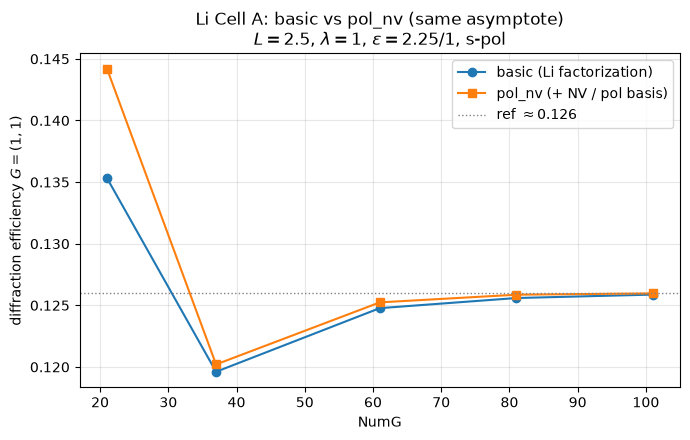

In [9]:
def diffraction_eff_G11(layers, wl, n_G, use_pol_nv, pol="s"):
    inc, _ = rcwa_poynting_flux_d(
        layers, wl, n_G=n_G, Lr=Lr, pol=pol, which_layer=0, use_pol_nv=use_pol_nv,
    )
    fwd, _bwd, G = rcwa_poynting_by_order_d(
        layers, wl, n_G=n_G, Lr=Lr, pol=pol, which_layer=2, use_pol_nv=use_pol_nv,
    )
    idx = next((i for i, g in enumerate(G) if tuple(g) == (1, 1)), None)
    if idx is None:
        return len(G), float("nan")
    e = float(np.real(fwd[idx])) / max(float(np.real(inc)), 1e-30)
    return len(G), e


curves = {}
for label, use_pol in (("basic", False), ("pol_nv", True)):
    num_g, eff = [], []
    for ng in ngs:
        nG_act, e = diffraction_eff_G11(layers_li, wl_li, ng, use_pol, pol="s")
        num_g.append(nG_act)
        eff.append(e)
        print(f"{label:6s} n_G={ng:3d} NumG={nG_act:3d}  eff_G11={e:.6f}")
    curves[label] = {"NumG": num_g, "eff": np.asarray(eff)}
    d = np.abs(np.diff(curves[label]["eff"]))
    print(f"  mean successive |Δ| = {d.mean():.3e}")

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(curves["basic"]["NumG"], curves["basic"]["eff"], "C0-o", label="basic (Li factorization)")
ax.plot(curves["pol_nv"]["NumG"], curves["pol_nv"]["eff"], "C1-s", label="pol_nv (+ NV / pol basis)")
ax.axhline(0.126, color="0.5", ls=":", lw=1, label=r"ref $\approx 0.126$")
ax.set_xlabel("NumG")
ax.set_ylabel(r"diffraction efficiency $G=(1,1)$")
ax.set_title("Li Cell A: basic vs pol_nv (same asymptote)\n"
             r"$L=2.5$, $\lambda=1$, $\varepsilon=2.25/1$, s-pol")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


核对：两条曲线应在 \(n_G\gtrsim 61\) 后都靠近 \(\approx 0.126\)；相邻点 \(|\Delta|\) 同量级。此处 **basic 并不更差**——差异主要在小 \(n_G\) 的瞬态，而非渐近收敛速度。


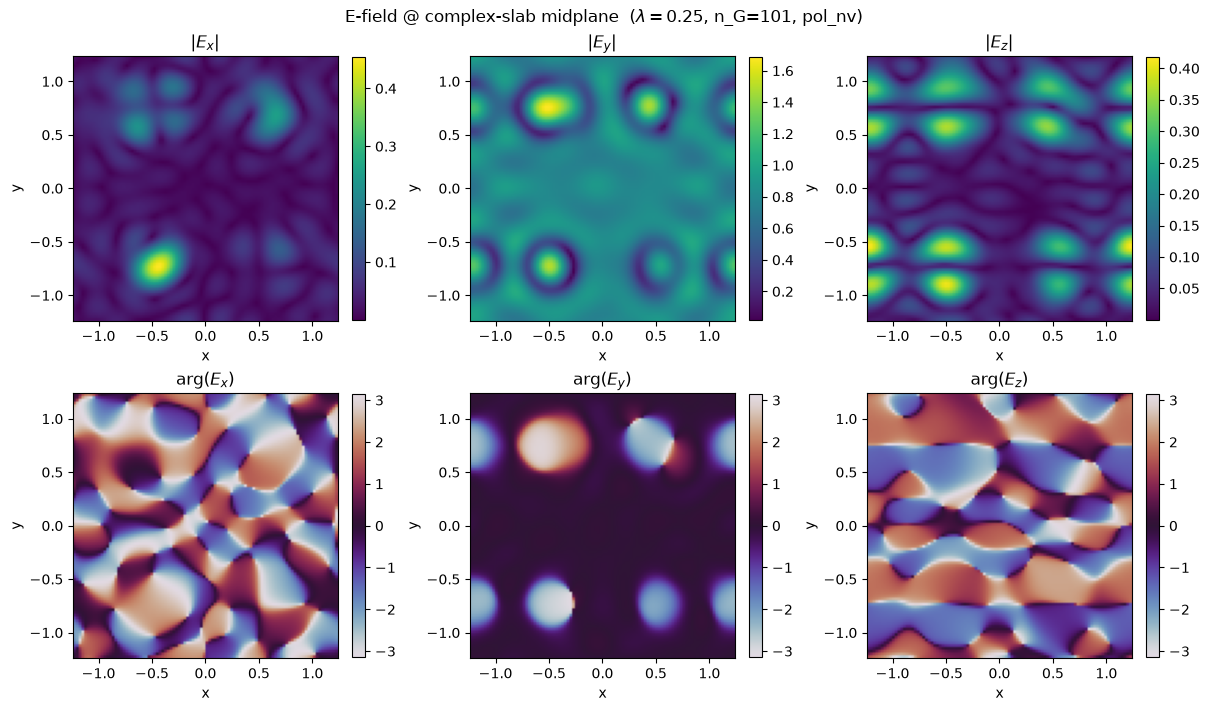

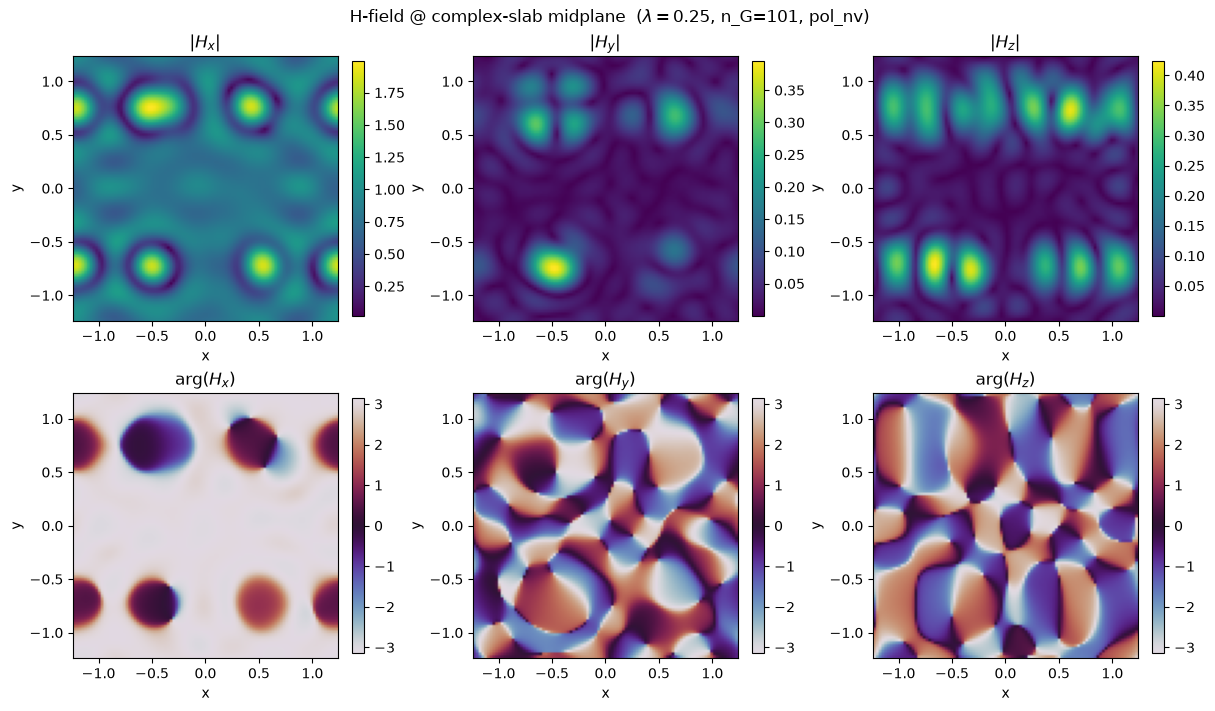

In [10]:
# Final fields on complex pattern at shorter wavelength (pol_nv)
n_G_final = ngs[-1]
E, H = rcwa_fields_on_grid_d(
    layers_complex, wl_field, nxy_field,
    n_G=n_G_final, Lr=Lr, pol="s",
    which_layer=1, z_offset=0.5 * depth_slab, use_pol_nv=True,
)
assert E.shape == (nxy_field[1], nxy_field[0], 3), E.shape
assert H.shape == (nxy_field[1], nxy_field[0], 3), H.shape

xs = np.linspace(-L / 2, L / 2, nxy_field[0], endpoint=False) + 0.5 * L / nxy_field[0]
ys = np.linspace(-L / 2, L / 2, nxy_field[1], endpoint=False) + 0.5 * L / nxy_field[1]
extent = [xs[0], xs[-1], ys[0], ys[-1]]
comp_names = ("x", "y", "z")


def plot_field_mag_phase(F, title_prefix, cmap_mag="viridis"):
    fig, axes = plt.subplots(2, 3, figsize=(12.0, 7.0), constrained_layout=True)
    for c, name in enumerate(comp_names):
        mag = np.abs(F[:, :, c])
        phase = np.angle(F[:, :, c])
        im0 = axes[0, c].imshow(mag, origin="lower", extent=extent, cmap=cmap_mag, aspect="equal")
        axes[0, c].set_title(rf"$|{title_prefix}_{name}|$")
        fig.colorbar(im0, ax=axes[0, c], fraction=0.046)
        im1 = axes[1, c].imshow(phase, origin="lower", extent=extent, cmap="twilight",
                                aspect="equal", vmin=-np.pi, vmax=np.pi)
        axes[1, c].set_title(rf"$\arg({title_prefix}_{name})$")
        fig.colorbar(im1, ax=axes[1, c], fraction=0.046)
        for ax in (axes[0, c], axes[1, c]):
            ax.set_xlabel("x")
            ax.set_ylabel("y")
    fig.suptitle(
        f"{title_prefix}-field @ complex-slab midplane  "
        rf"($\lambda={wl_field}$, n_G={n_G_final}, pol_nv)",
        fontsize=12,
    )
    plt.show()


plot_field_mag_phase(E, "E")
plot_field_mag_phase(H, "H")


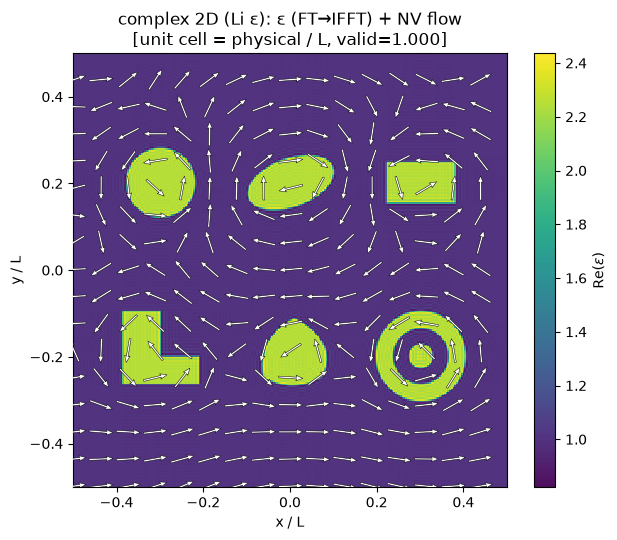

In [11]:
# ε + NV flow for the same complex pattern (unit-cell twin; style matches plot_flow above)
grid_unit = grid_info_2d_s.create_bloch_mode_fourier(
    [nu, nv], wavelength, 0.0, NA,
    [[-0.5, -0.5], [0.5, 0.5]],
)


def epsilon_ifft_from_layer_grid(lyr, grid):
    fft = raster_layer_fourier_transform_s(lyr, grid, wavelength)
    xsize, ysize = grid.shape
    spec = np.asarray(fft, dtype=np.complex64).reshape((ysize, xsize))
    return (xsize * ysize) * np.fft.fftshift(np.fft.ifft2(spec))


eps_complex = epsilon_ifft_from_layer_grid(lyr_flow, grid_unit)
eps_show = np.real(eps_complex)

vf = rcwa_pol_nv_flow_field_s(lyr_flow, nu, nv, unit_normalize=False)
assert vf.shape == (nu, nv, 2), vf.shape
vx, vy = vf[:, :, 0], vf[:, :, 1]
mag = np.hypot(vx, vy)
thr = max(1e-12, 1e-3 * np.max(mag))
valid = mag > thr
vxn = np.zeros_like(vx)
vyn = np.zeros_like(vy)
vxn[valid] = vx[valid] / mag[valid]
vyn[valid] = vy[valid] / mag[valid]

xs_u = np.linspace(-0.5, 0.5, nu, endpoint=False) + 0.5 / nu
ys_u = np.linspace(-0.5, 0.5, nv, endpoint=False) + 0.5 / nv
X_u, Y_u = np.meshgrid(xs_u, ys_u, indexing="ij")

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.pcolormesh(xs_u, ys_u, eps_show, shading="auto", cmap="viridis", alpha=0.95)
fig.colorbar(im, ax=ax, fraction=0.046, label=r"$\mathrm{Re}(\varepsilon)$")
s = quiver_stride
ax.quiver(
    X_u[::s, ::s], Y_u[::s, ::s], vxn[::s, ::s], vyn[::s, ::s],
    color="white", edgecolor="black", linewidth=0.35,
    angles="xy", scale_units="xy", scale=18, width=0.004,
    headwidth=3.2, headlength=4.0, headaxislength=3.5, pivot="mid", zorder=3,
)
ax.set_title(
    f"complex 2D (Li ε): ε (FT→IFFT) + NV flow\n"
    f"[unit cell = physical / L, valid={float(np.mean(valid)):.3f}]"
)
ax.set_aspect("equal")
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 0.5)
ax.set_xlabel("x / L")
ax.set_ylabel("y / L")
plt.tight_layout()
plt.show()
